# Footprints before the 8-K

**Gator Quant Hacks 2026 · Massive Challenge · Trade the 8-K**

## Hypothesis

Material corporate events leak before they are public. People who know early (deal teams, insiders,
the people they talk to) prefer short-dated, out-of-the-money options for the leverage, and that leaves
a footprint in the option chain **before** the announcement. The 8-K, filed up to four business days
after the event, then tells everyone *what* happened. Our claim: when a **leak-prone** 8-K follows
abnormal, directional pre-announcement option flow, the market under-uses the footprint it already saw,
and the stock keeps drifting the way the flow pointed.

- **Category**: a pooled set of leak-prone tags (M&A, guidance, restructuring, business exits, CEO and
  executive changes, buybacks, offerings, litigation). One tag on 100 names is too few events.
- **Signal**: abnormal option volume in the 5 sessions before the announcement, with its direction read
  from (a) the shift in out-of-the-money call vs put volume and (b) the change in the risk reversal
  (OTM call IV minus OTM put IV), which tells us which side was *paying up*.
- **Strategy**: **1 · Long call** after a bullish footprint (headline); **3 · Protective put** after a
  bearish one (second leg).
- **Entry**: close of the filing session `t_0`, so the trade is only taken once the 8-K category is known.
  Every input to the signal is from before the announcement.

Prior work: Augustin, Brenner & Subrahmanyam (2019) find abnormal OTM call volume ahead of M&A
announcements; Pan & Poteshman (2006) and Cremers & Weinbaum (2010) find option flow and skew predict
stock returns. The link to *8-K categories*, and the test below, are ours.

## The design: a 2 × 2, not a placebo line

|  | Abnormal directional flow | Quiet flow |
|---|---|---|
| **Leak-prone 8-K follows** | **A** | **B** |
| **Ordinary day, same names** | **C** | **D** |

The finding is the difference-in-differences **(A − B) − (C − D)**. It answers the strongest objection
("option flow predicts returns on any day, the 8-K adds nothing"). Negative-control categories with
nothing to leak (director appointments, equity grants, charter amendments) and one where pre-event
volume is anticipation rather than information (scheduled quarterly earnings) should show no edge.

## Pre-registered predictions (written before looking at results)

1. **P1 · Direction.** For leak-prone events, signed stock drift after `t_0` is positive in the direction
   of the footprint, and larger than after the same footprint on ordinary days.
2. **P2 · Decay.** The edge is concentrated at short horizons (h = 1-10 sessions) and is gone by h = 42.
3. **P3 · Controls.** Negative-control categories show no BULL-minus-QUIET edge.
4. **P4 · Fragility.** The top 100 are mostly *acquirers*, not targets, and leakage is weaker for
   acquirers. Expect a smaller effect than the M&A-target literature and wide intervals. If the sealed
   window shows no effect, the small flagged sample (roughly 15-25% of events) is the reason we name now.

## How to run

1. Put `MASSIVE_API_KEY=...` in `.env` beside this notebook (same as the starter).
2. Set `SMOKE_TEST = True` in section 2 for a few-minute plumbing check, then `False` for the real run.
3. Run all. Responses are cached in `.massive_cache/` (shared with the starter notebook), so reruns take
   seconds. Judges: set the sealed dates and `RUN_HOLDOUT = True` in section 2.

## 1 · API client

Same as the starter (`api_get` caches every response on disk by URL, `api_get_all` follows pagination),
with two changes: one HTTP session per thread, and atomic cache writes, so `pmap` can fetch in parallel.

In [1]:
import os, json, time, hashlib, re, math, threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from pandas.tseries.holiday import (AbstractHolidayCalendar, Holiday, nearest_workday, USMartinLutherKingJr,
                                    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay, USThanksgivingDay)
from pandas.tseries.offsets import CustomBusinessDay

BASE_URL = "https://api.massive.com"


def load_api_key(name: str = "MASSIVE_API_KEY") -> str:
    """Environment first, then a `.env` file beside the notebook, then a prompt. Never paste a key into a cell."""
    key = (os.environ.get(name) or "").strip()
    env_file = Path(".env")
    if not key and env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith(f"{name}="):
                key = line.split("=", 1)[1].strip().strip('"').strip("'")
    if not key:
        key = getpass(f"{name} (https://massive.com/dashboard/keys): ").strip()
    return key


API_KEY = load_api_key()
_local = threading.local()


def _session() -> requests.Session:
    s = getattr(_local, "session", None)
    if s is None:
        s = requests.Session()
        s.headers["Authorization"] = f"Bearer {API_KEY}"
        _local.session = s
    return s


CACHE_DIR = Path(".massive_cache")
CACHE_DIR.mkdir(exist_ok=True)


def api_get(path_or_url: str, params: dict | None = None) -> dict:
    """GET one page from the Massive REST API. Cached on disk by the full URL, so reruns are free."""
    url = path_or_url if path_or_url.startswith("http") else BASE_URL + path_or_url
    full_url = requests.Request("GET", url, params=params).prepare().url
    cache_file = CACHE_DIR / (hashlib.sha1(full_url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        return json.loads(cache_file.read_text())
    for attempt in range(10):
        resp = _session().get(full_url, timeout=60)
        if resp.status_code in (429, 500, 502, 503, 504):
            retry_after = resp.headers.get("Retry-After", "")
            time.sleep(float(retry_after) if retry_after.isdigit() else min(2 ** attempt, 20))
            continue
        break
    resp.raise_for_status()
    payload = resp.json()
    tmp = cache_file.with_suffix(f".{threading.get_ident()}.tmp")
    tmp.write_text(json.dumps(payload))
    tmp.replace(cache_file)
    return payload


def api_get_all(path: str, params: dict | None = None, max_pages: int = 500) -> list[dict]:
    """Follow `next_url` pagination and return every result row."""
    payload = api_get(path, params)
    rows = list(payload.get("results") or [])
    pages = 1
    while payload.get("next_url") and pages < max_pages:
        payload = api_get(payload["next_url"])
        rows.extend(payload.get("results") or [])
        pages += 1
    return rows


def pmap(fn, items, label: str = "", every: int = 50) -> list:
    """Run `fn` over `items` on N_THREADS threads, keeping order. A failed item becomes None (first errors printed)."""
    items = list(items)
    out, errors, t0 = [None] * len(items), 0, time.time()
    with ThreadPoolExecutor(N_THREADS) as ex:
        futures = {ex.submit(fn, it): i for i, it in enumerate(items)}
        for n, f in enumerate(as_completed(futures), 1):
            try:
                out[futures[f]] = f.result()
            except Exception as e:
                errors += 1
                if errors <= 3:
                    print(f"  {label}: item {futures[f]} failed: {type(e).__name__}: {e}")
            if label and n % every == 0:
                print(f"  {label}: {n}/{len(items)} ({time.time() - t0:.0f}s)")
    if label:
        print(f"  {label}: {len(items)} done in {time.time() - t0:.0f}s, {errors} failed")
    return out


print(f"API key loaded (ends {API_KEY[-4:]}); cache at {CACHE_DIR.resolve()}")

API key loaded (ends jNOD); cache at /Users/lalitboyapati/Documents/projects/GQHacks/massive/gqh-massive-8k-starter/.massive_cache


## 2 · Configuration

Everything a team may change is here. `HORIZONS` are fixed by the organizers. The footprint parameters
have neighbours in their `_GRID` lists; section 10 walks them.

In [2]:
SMOKE_TEST = False          # True: a few-minute run on a handful of events to check the plumbing (numbers meaningless)

# ---- Categories ------------------------------------------------------------------------------------
LEAK_TAGS = [               # material, non-scheduled events that someone knows about before the public does
    "acquisition_agreement", "guidance_issuance_or_update", "restructuring_plan", "business_line_exit",
    "ceo_appointment", "executive_officer_departure", "share_repurchase_program", "public_offering",
    "material_litigation",
]
CONTROL_TAGS = [            # nothing to leak, or scheduled (pre-event volume is anticipation, not information)
    "quarterly_earnings", "director_appointment", "equity_compensation_grant", "charter_amendment",
]

# ---- Windows (same as the starter) -----------------------------------------------------------------
STUDY_START, STUDY_END = "2024-01-01", "2025-12-31"      # in-sample
OOS_START, OOS_END = "2026-01-01", "2026-08-31"          # out-of-sample
HOLDOUT_START, HOLDOUT_END = "2023-06-01", "2023-08-31"  # sealed: judges change these and flip RUN_HOLDOUT
RUN_HOLDOUT = False

TOP_100 = """
AAPL ABBV ABT ACN ADBE AIG AMD AMGN AMT AMZN AVGO AXP BA BAC BK BKNG BLK BMY BRK.B C
CAT CHTR CL CMCSA COF COP COST CRM CSCO CVS CVX DE DHR DIS DUK EMR FDX GD GE GILD
GM GOOGL GS HD HON IBM INTC INTU ISRG JNJ JPM KO LIN LLY LMT LOW MA MCD MDLZ MDT
MET META MMM MO MRK MS MSFT NEE NFLX NKE NOW NVDA ORCL PEP PFE PG PLTR PM PYPL QCOM
RTX SBUX SCHW SO T TGT TMO TMUS TSLA TXN UBER UNH UNP UPS USB V VZ WFC WMT XOM
""".split()
assert len(TOP_100) == 100 and len(set(TOP_100)) == 100

# ---- Trade construction (as in the starter) --------------------------------------------------------
EXPIRY_BUCKETS = {"1m": (21, 45, 30), "2m": (46, 80, 60), "3-6m": (90, 180, 120)}
BASELINE_BUCKET = "3-6m"    # headline bucket: lives long enough to be judged at every fixed horizon
HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]     # fixed for every team. Do not change.
OTM_PCT = 0.05
OTM_GRID = [0.03, 0.05, 0.10]
ENTRY = "post"              # close of the filing session: the tradeable rule
RISK_FREE = 0.04
STRIKE_WINDOW = 0.25
MAX_STALE_SESSIONS = 3

# ---- The footprint signal --------------------------------------------------------------------------
FLOW_WINDOW = 5                     # sessions ending the session before the announcement
FLOW_WINDOW_GRID = [3, 5, 10]
FLOW_BASELINE = 20                  # sessions before the window that define "normal" for this name
FLOW_MONEYNESS = [0.0, 0.03, 0.06, 0.10]    # strikes sampled each side of spot, per expiry
FLOW_OTM_MIN = 0.03                 # a contract at least this far OTM counts toward the call/put share
FLOW_RR_MONEYNESS = 0.06            # the OTM call and put whose IV gap is the risk reversal
FLOW_EXPIRY_DAYS = (20, 75)         # calendar days after the window's last session; monthlies preferred
FLOW_N_EXPIRIES = 2
AV_HI_Q, AV_LO_Q = 0.80, 0.50       # abnormal = above the 80th pct of ordinary days; quiet = below the median
AV_HI_Q_GRID = [0.70, 0.80, 0.90]
DIRECTION_RULE = "both"             # "both": call share and risk reversal agree (falls back to call share if RR is missing); "cs"; "rr"
ANN_LOOKBACK_DAYS = 14              # announcement date = earliest date in the filing text, at most this many days before filing
FROZEN_THRESHOLDS = None            # None: learn from the in-sample placebo. Or a dict to pin them.

# ---- Placebo and controls --------------------------------------------------------------------------
N_PLACEBO = 400                     # ordinary days (cells C and D); larger than the starter's 120 because only the top 20% are "abnormal"
N_PLACEBO_OOS = 200
PLACEBO_GAP_DAYS = 30
RUN_NEGATIVE_CONTROLS = True

# ---- Mechanics -------------------------------------------------------------------------------------
MAX_EVENTS = None
N_THREADS = 8
FETCH_ACCEPTANCE_TIMES = False      # True needs a real contact in SEC_USER_AGENT; fixes after-the-bell filings
SEC_USER_AGENT = "GatorQuantHacks team-name your@email.edu"

if SMOKE_TEST:
    MAX_EVENTS, N_PLACEBO, N_PLACEBO_OOS = 12, 30, 20

assert OTM_PCT in OTM_GRID and BASELINE_BUCKET in EXPIRY_BUCKETS and ENTRY in ("pre", "post")
assert FLOW_WINDOW in FLOW_WINDOW_GRID and AV_HI_Q in AV_HI_Q_GRID and FLOW_RR_MONEYNESS in FLOW_MONEYNESS
assert DIRECTION_RULE in ("both", "cs", "rr")
for _name in ("STUDY_START", "STUDY_END", "OOS_START", "OOS_END", "HOLDOUT_START", "HOLDOUT_END"):
    pd.Timestamp(globals()[_name])
assert STUDY_START < STUDY_END and OOS_START < OOS_END and HOLDOUT_START < HOLDOUT_END

## 3 · Trading calendar

Copied from the starter: weekdays minus NYSE full-day closures.

In [3]:
class NYSEHolidays(AbstractHolidayCalendar):
    rules = [
        Holiday("New Year's Day", month=1, day=1,
                observance=lambda d: d + pd.Timedelta(days=1) if d.weekday() == 6 else d),
        USMartinLutherKingJr, USPresidentsDay, GoodFriday, USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01", observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay, USThanksgivingDay,
        Holiday("Christmas Day", month=12, day=25, observance=nearest_workday),
        Holiday("National day of mourning, President Carter", year=2025, month=1, day=9),
    ]


def trading_sessions(start, end) -> pd.DatetimeIndex:
    holidays = NYSEHolidays().holidays(pd.Timestamp(start) - pd.Timedelta(days=7), pd.Timestamp(end) + pd.Timedelta(days=7))
    return pd.bdate_range(start, end, freq=CustomBusinessDay(holidays=holidays))


CAL = trading_sessions("2021-06-01", "2027-12-31")
TODAY = pd.Timestamp.today().normalize()
LAST_SESSION = CAL[CAL.searchsorted(TODAY, side="right") - 1]


def session_on_or_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left")]


def session_before(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left") - 1]


def sessions_between(a, b) -> int:
    """Number of sessions strictly after `a` up to and including `b`."""
    return int(CAL.searchsorted(pd.Timestamp(b), side="right") - CAL.searchsorted(pd.Timestamp(a), side="right"))


print(f"{len(CAL)} sessions in the calendar; last completed session {LAST_SESSION.date()}")

1655 sessions in the calendar; last completed session 2026-10-02


## 4 · Events, and when the news actually broke

Three dates per event:

- **`t_ann`, the announcement session.** An 8-K is filed up to four business days *after* the event, and
  option flow after the press release is the public reacting, not a footprint. `supporting_text` usually
  opens with the event date ("On March 3, 2025, the Company entered into..."). We take the earliest date
  in the text that falls within `ANN_LOOKBACK_DAYS` before the filing; if there is none, the filing date.
  **The signal window ends the session before `t_ann`.**
- **`t_0`, the filing session**: entry at its close, once the category is known.
- **`t_pre`**: the session before `t_0`, where the chain is read for pricing (as in the starter).

A filing that carries several leak-prone tags is one event; `tag` is the first in `LEAK_TAGS` order and
`tags` lists all of them.

In [4]:
_MONTHS = {m: i for i, m in enumerate("jan feb mar apr may jun jul aug sep oct nov dec".split(), 1)}
_DATE_WORDS = re.compile(r"\b(Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|June?|July?|Aug(?:ust)?|"
                         r"Sep(?:t(?:ember)?)?|Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)\.?\s+(\d{1,2}),?\s+(\d{4})", re.I)
_DATE_NUMS = re.compile(r"\b(\d{1,2})/(\d{1,2})/(\d{4})\b")


def dates_in_text(text: str) -> list[pd.Timestamp]:
    out = []
    for m in _DATE_WORDS.finditer(text or ""):
        try:
            out.append(pd.Timestamp(int(m.group(3)), _MONTHS[m.group(1)[:3].lower()], int(m.group(2))))
        except ValueError:
            pass
    for m in _DATE_NUMS.finditer(text or ""):
        try:
            out.append(pd.Timestamp(int(m.group(3)), int(m.group(1)), int(m.group(2))))
        except ValueError:
            pass
    return out


def announcement_date(text: str, filing_date) -> pd.Timestamp:
    """Earliest date written in the filing text that is on or before the filing date and within the lookback."""
    filing_date = pd.Timestamp(filing_date)
    lo = filing_date - pd.Timedelta(days=ANN_LOOKBACK_DAYS)
    cand = [d for d in dates_in_text(text) if lo <= d <= filing_date]
    return min(cand) if cand else filing_date


def normalize_ticker(t) -> str | None:
    if not isinstance(t, str) or not t.strip():
        return None
    return t.strip().upper().replace("/", ".")


def fetch_disclosures(tag: str, start: str, end: str) -> pd.DataFrame:
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {
        "tertiary_category": tag, "filing_date.gte": start, "filing_date.lte": end,
        "limit": 1000, "sort": "filing_date.asc",
    })
    df = pd.DataFrame(rows)
    if not df.empty:
        df["filing_date"] = pd.to_datetime(df["filing_date"])
        df["tag"] = tag
    return df


def fetch_acceptance_time(filing_url: str) -> pd.Timestamp | None:
    """Acceptance timestamp (US/Eastern) from the EDGAR submission header; None if not found."""
    key = CACHE_DIR / ("sec_" + hashlib.sha1(filing_url.encode()).hexdigest() + ".txt")
    if key.exists():
        head = key.read_text()
    else:
        resp = requests.get(filing_url, headers={"User-Agent": SEC_USER_AGENT}, timeout=30, stream=True)
        resp.raise_for_status()
        head = next(resp.iter_content(4096, decode_unicode=True))
        key.write_text(head)
        time.sleep(0.12)
    m = re.search(r"<ACCEPTANCE-DATETIME>(\d{14})", head)
    return pd.Timestamp(m.group(1)) if m else None


def build_events(tags: list[str], start: str, end: str, universe: list[str] = TOP_100) -> pd.DataFrame:
    """One row per (filer, filing date) in the universe across `tags`, with t_ann, t_0 and t_pre."""
    frames = [f for f in (fetch_disclosures(t, start, end) for t in tags) if not f.empty]
    cols = ["cik", "filing_date", "ticker", "tag", "tags", "accession_number", "filing_url", "supporting_text"]
    if not frames:
        return pd.DataFrame(columns=cols + ["t_0", "t_pre", "ann_date", "t_ann", "ann_lag_sessions", "event_date"])
    ex = pd.concat(frames, ignore_index=True).explode("tickers").rename(columns={"tickers": "ticker"})
    ex["ticker"] = ex["ticker"].map(normalize_ticker)
    ex = ex[ex["ticker"].isin(universe)].copy()
    ex["tag_rank"] = ex["tag"].map({t: i for i, t in enumerate(tags)})
    join = lambda s: " | ".join(dict.fromkeys(x for x in s if isinstance(x, str)))
    ev = (ex.sort_values(["cik", "filing_date", "tag_rank"])
            .groupby(["cik", "filing_date"], as_index=False)
            .agg(ticker=("ticker", "first"), tag=("tag", "first"), tags=("tag", lambda s: ",".join(dict.fromkeys(s))),
                 accession_number=("accession_number", "first"), filing_url=("filing_url", "first"),
                 supporting_text=("supporting_text", join))
            .sort_values("filing_date").reset_index(drop=True))
    ev["t_0"] = ev["filing_date"].map(session_on_or_after)
    if FETCH_ACCEPTANCE_TIMES and len(ev):
        acc = pd.Series([fetch_acceptance_time(u) for u in ev["filing_url"]], index=ev.index)
        late = acc.notna() & (acc.dt.normalize() == ev["t_0"]) & (acc.dt.hour >= 16)
        ev.loc[late, "t_0"] = [CAL[CAL.searchsorted(d, side="right")] for d in ev.loc[late, "t_0"]]
        ev["accepted_at"] = acc
    ev["t_pre"] = ev["t_0"].map(session_before)
    ev["ann_date"] = [announcement_date(t, f) for t, f in zip(ev["supporting_text"], ev["filing_date"])]
    ev["t_ann"] = [min(session_on_or_after(a), t0) for a, t0 in zip(ev["ann_date"], ev["t_0"])]
    ev["ann_lag_sessions"] = [sessions_between(a, t0) for a, t0 in zip(ev["t_ann"], ev["t_0"])]
    ev["event_date"] = ev["filing_date"]
    return ev


def known_8k_dates(*frames: pd.DataFrame) -> dict[str, list[pd.Timestamp]]:
    """Every 8-K date we know of per ticker, so ordinary days can stay clear of all of them."""
    both = pd.concat([f[["ticker", "filing_date", "t_ann"]] for f in frames if len(f)], ignore_index=True)
    long = pd.concat([both[["ticker", "filing_date"]].rename(columns={"filing_date": "d"}),
                      both[["ticker", "t_ann"]].rename(columns={"t_ann": "d"})])
    return long.groupby("ticker")["d"].apply(lambda s: sorted(set(s))).to_dict()


def sample_placebo(ev: pd.DataFrame, n: int, start: str, end: str, avoid: dict, seed: int = 7) -> pd.DataFrame:
    """Ordinary sessions for the event tickers (in proportion to their event counts), clear of every known 8-K."""
    rng = np.random.default_rng(seed)
    sessions = CAL[(CAL >= pd.Timestamp(start)) & (CAL <= min(pd.Timestamp(end), LAST_SESSION))]
    rows = []
    for t in rng.choice(ev["ticker"].to_numpy(), size=n, replace=True):
        for _ in range(50):
            d = sessions[rng.integers(len(sessions))]
            if all(abs((d - a).days) > PLACEBO_GAP_DAYS for a in avoid.get(t, [])):
                rows.append({"ticker": t, "tag": "placebo", "filing_date": d, "event_date": d, "t_ann": d, "t_0": d,
                             "t_pre": session_before(d), "ann_lag_sessions": 0})
                break
    return pd.DataFrame(rows).drop_duplicates(["ticker", "event_date"]).reset_index(drop=True)


def limit_events(ev: pd.DataFrame, n: int | None) -> pd.DataFrame:
    return ev if not n or len(ev) <= n else ev.sample(n, random_state=0).sort_values("filing_date").reset_index(drop=True)


events = limit_events(build_events(LEAK_TAGS, STUDY_START, STUDY_END), MAX_EVENTS)
control_events = build_events(CONTROL_TAGS, STUDY_START, STUDY_END)
print(f"{len(events)} leak-prone events across {events.ticker.nunique()} tickers; "
      f"{len(control_events)} negative-control events")
display(events.groupby("tag").size().rename("events").to_frame().T)
print(f"Announcement date found in the text and earlier than the filing for {(events.ann_lag_sessions > 0).mean():.0%} of events; "
      f"median lag {events.ann_lag_sessions.median():.0f} sessions, max {events.ann_lag_sessions.max()}")
with pd.option_context("display.max_colwidth", 110):
    display(events[["ticker", "tag", "filing_date", "ann_date", "t_ann", "t_0", "supporting_text"]].sample(min(5, len(events)), random_state=1))

318 leak-prone events across 92 tickers; 284 negative-control events


tag,acquisition_agreement,business_line_exit,ceo_appointment,executive_officer_departure,guidance_issuance_or_update,material_litigation,public_offering,restructuring_plan,share_repurchase_program
events,29,9,17,129,59,11,17,14,33


Announcement date found in the text and earlier than the filing for 30% of events; median lag 0 sessions, max 10


,ticker,tag,filing_date,ann_date,t_ann,t_0,supporting_text
123,INTU,guidance_issuance_or_update,2024-11-21,2024-11-21,2024-11-21,2024-11-21,"On November 21, 2024, Intuit Inc. announced its financial results for the fiscal quarter ended October 31,..."
110,SCHW,ceo_appointment,2024-10-01,2024-09-30,2024-09-30,2024-10-01,"On September 30, 2024, the Board appointed Richard A. Wurster to succeed Mr. Bettinger as CEO, effective a..."
80,BA,acquisition_agreement,2024-07-01,2024-07-01,2024-07-01,2024-07-01,"On the terms and subject to the conditions set forth in the Merger Agreement, at the effective time of the..."
131,ABBV,executive_officer_departure,2024-12-13,2024-12-11,2024-12-11,2024-12-13,"On December 11, 2024, Kevin K. Buckbee, Senior Vice President, Controller, informed AbbVie that he plans t..."
132,TMUS,share_repurchase_program,2024-12-13,2024-12-13,2024-12-13,2024-12-13,The Board has authorized a new shareholder return program of up to an initial $14.0 billion that will run ...


## 5 · Option chain, spot from parity, and the leg engine

Copied from the starter (sections 5-6): the chain as of a date, spot recovered by put-call parity, expiry
and strike pickers, `Leg` / `PricedEvent`, and the P&L of the five strategies per $1 of spot. `price_events`
now runs in parallel.

In [5]:
def option_bars(opt_ticker: str, start, end) -> pd.DataFrame:
    """Daily bars for one contract: index = session, columns close and volume. Only sessions where it traded."""
    rows = api_get_all(f"/v2/aggs/ticker/{opt_ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": "false", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"close": [float(r["c"]) for r in rows], "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def fetch_chain(ticker: str, as_of: pd.Timestamp, dte_lo: int, dte_hi: int) -> pd.DataFrame:
    """Every standard contract that existed on `as_of` with an expiry `dte_lo`..`dte_hi` days out."""
    rows = api_get_all("/v3/reference/options/contracts", {
        "underlying_ticker": ticker, "as_of": as_of.strftime("%Y-%m-%d"),
        "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
        "expiration_date.lte": (as_of + pd.Timedelta(days=dte_hi)).strftime("%Y-%m-%d"),
        "limit": 1000,
    })
    chain = pd.DataFrame(rows)
    if chain.empty:
        return chain
    if "shares_per_contract" in chain:
        chain = chain[chain["shares_per_contract"].fillna(100) == 100]
    chain = chain[["ticker", "contract_type", "strike_price", "expiration_date"]].copy()
    chain["expiration_date"] = pd.to_datetime(chain["expiration_date"])
    chain["dte"] = (chain["expiration_date"] - as_of).dt.days
    chain["strike_price"] = chain["strike_price"].astype(float)
    return chain.reset_index(drop=True)


def paired_strikes(e: pd.DataFrame) -> np.ndarray:
    both = e.groupby("strike_price")["contract_type"].nunique()
    return both[both == 2].index.to_numpy(dtype=float)


def contract(e: pd.DataFrame, strike: float, kind: str) -> str:
    return e[(e.strike_price == strike) & (e.contract_type == kind)]["ticker"].iloc[0]


def last_close_on_or_before(opt_ticker: str, day: pd.Timestamp, lookback_days: int = 7) -> float | None:
    bars = option_bars(opt_ticker, day - pd.Timedelta(days=lookback_days), day)
    return float(bars["close"].iloc[-1]) if len(bars) else None


def locate_spot(chain: pd.DataFrame, day: pd.Timestamp, max_iter: int = 8) -> dict | None:
    """Stock price on `day` from the chain alone: S = K·e^(−rT) + C − P at the strike nearest the estimate."""
    near = chain[chain.dte >= 3]
    if near.empty:
        return None
    near = near[near.dte == near.dte.min()]
    strikes = paired_strikes(near)
    if len(strikes) < 3:
        return None
    T = near.dte.iloc[0] / 365
    k, tried, est = float(np.median(strikes)), set(), None
    k = strikes[np.abs(strikes - k).argmin()]
    for _ in range(max_iter):
        tried.add(k)
        c = last_close_on_or_before(contract(near, k, "call"), day)
        p = last_close_on_or_before(contract(near, k, "put"), day)
        if c is None or p is None:
            rest = [s for s in strikes if s not in tried]
            if not rest:
                break
            k = rest[int(np.abs(np.array(rest) - k).argmin())]
            continue
        est = k * np.exp(-RISK_FREE * T) + c - p
        k_new = strikes[np.abs(strikes - est).argmin()]
        if k_new == k or k_new in tried:
            break
        k = k_new
    if est is None:
        return None
    return {"spot": float(est), "strike": float(k), "expiry": near.expiration_date.iloc[0], "dte": int(near.dte.iloc[0])}


def pick_expiry(chain: pd.DataFrame, lo: int, hi: int, target: int) -> pd.Timestamp | None:
    cand = chain[(chain.dte >= lo) & (chain.dte <= hi)]
    if cand.empty:
        return None
    dte_of = cand.groupby("expiration_date")["dte"].first()
    ok = [x for x, g in cand.groupby("expiration_date") if len(paired_strikes(g)) >= 3]
    if not ok:
        return None
    return min(ok, key=lambda x: abs(dte_of[x] - target))


def select_strikes(e: pd.DataFrame, spot: float, otm_pcts: list[float]) -> dict[str, float] | None:
    both = paired_strikes(e)
    both = both[(both >= spot * (1 - STRIKE_WINDOW)) & (both <= spot * (1 + STRIKE_WINDOW))]
    if len(both) == 0:
        return None
    calls = np.sort(e.loc[e.contract_type == "call", "strike_price"].unique())
    puts = np.sort(e.loc[e.contract_type == "put", "strike_price"].unique())
    out = {"K": float(both[np.abs(both - spot).argmin()])}
    for pct in otm_pcts:
        up, dn = calls[calls >= spot * (1 + pct)], puts[puts <= spot * (1 - pct)]
        out[f"U{pct}"] = float(up.min()) if len(up) else float(calls.max())
        out[f"L{pct}"] = float(dn.max()) if len(dn) else float(puts.min())
    return out


def mark_bars(bars: pd.DataFrame, day) -> float:
    """Last traded close on or before `day`, if it is at most MAX_STALE_SESSIONS sessions old."""
    b = bars.loc[: pd.Timestamp(day)]
    if b.empty or sessions_between(b.index[-1], day) > MAX_STALE_SESSIONS:
        return np.nan
    return float(b["close"].iloc[-1])


@dataclass
class Leg:
    ticker: str
    kind: str
    strike: float
    bars: pd.DataFrame

    def mark(self, day) -> float:
        return mark_bars(self.bars, day)

    def volume_on(self, day) -> float:
        return float(self.bars["volume"].get(pd.Timestamp(day), 0.0))


@dataclass
class PricedEvent:
    ticker: str
    event_date: pd.Timestamp
    t_pre: pd.Timestamp
    t_0: pd.Timestamp
    bucket: str
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    spot_pre: float
    strikes: dict
    legs: dict

    def marks(self, day) -> dict[str, float]:
        return {name: leg.mark(day) for name, leg in self.legs.items()}

    def synthetic_spot(self, day, m: dict | None = None) -> float:
        m = m if m is not None else self.marks(day)
        T = max((self.expiry - pd.Timestamp(day)).days, 0) / 365
        return self.strikes["K"] * np.exp(-RISK_FREE * T) + m["C_K"] - m["P_K"]


def price_event(ticker, t_pre, t_0, event_date, buckets: dict, otm_pcts: list[float]) -> tuple[list, list[str]]:
    dte_hi = max(b[1] for b in buckets.values())
    chain = fetch_chain(ticker, t_pre, 2, dte_hi)
    if chain.empty:
        return [], ["no option chain as of the pre-event session"]
    loc = locate_spot(chain, t_pre)
    if loc is None:
        return [], ["could not recover spot from the chain"]
    priced, notes = [], []
    for name, (lo, hi, target) in buckets.items():
        expiry = pick_expiry(chain, lo, hi, target)
        if expiry is None:
            notes.append(f"{name}: no expiry {lo}-{hi} days out")
            continue
        e = chain[chain.expiration_date == expiry]
        strikes = select_strikes(e, loc["spot"], otm_pcts)
        if strikes is None:
            notes.append(f"{name}: no paired strikes near spot")
            continue
        wanted = {"C_K": ("call", strikes["K"]), "P_K": ("put", strikes["K"])}
        for pct in otm_pcts:
            wanted[f"C_U{pct}"] = ("call", strikes[f"U{pct}"])
            wanted[f"P_L{pct}"] = ("put", strikes[f"L{pct}"])
        legs = {}
        for key, (kind, k) in wanted.items():
            tk = contract(e, k, kind)
            legs[key] = Leg(tk, kind, k, option_bars(tk, t_pre - pd.Timedelta(days=10), expiry))
        pe = PricedEvent(ticker, event_date, t_pre, t_0, name, expiry, CAL[CAL.searchsorted(expiry, side="right") - 1],
                         loc["spot"], strikes, legs)
        if np.isnan(pe.legs["C_K"].mark(t_pre)) or np.isnan(pe.legs["P_K"].mark(t_pre)):
            notes.append(f"{name}: ATM pair did not trade on or near the pre-event session")
            continue
        priced.append(pe)
    return priced, notes


def price_events(ev: pd.DataFrame, buckets: dict = None, otm_pcts: list[float] = None, label: str = "pricing") -> tuple[list, pd.DataFrame]:
    buckets, otm_pcts = buckets or EXPIRY_BUCKETS, otm_pcts or OTM_GRID
    recs = ev.to_dict("records")
    got = pmap(lambda r: price_event(r["ticker"], r["t_pre"], r["t_0"], r["event_date"], buckets, otm_pcts), recs, label)
    priced, dropped = [], []
    for r, g in zip(recs, got):
        if g is None:
            dropped.append((r["ticker"], r["t_0"], "request failed"))
            continue
        priced += g[0]
        dropped += [(r["ticker"], r["t_0"], note) for note in g[1]]
    return priced, pd.DataFrame(dropped, columns=["ticker", "t_0", "reason"])


STRATEGIES = ["stock", "long_call", "covered_call", "protective_put", "collar", "cash_secured_put"]
STRATEGY_LABEL = {"stock": "Stock only (synthetic)", "long_call": "1 · Long call", "covered_call": "2 · Covered call",
                  "protective_put": "3 · Protective put", "collar": "4 · Collar", "cash_secured_put": "5 · Cash-secured put"}


def strategy_pnl(m_e: dict, m_x: dict, S_e: float, S_x: float, otm: float) -> dict[str, float]:
    dS = S_x - S_e
    dC_U = m_x[f"C_U{otm}"] - m_e[f"C_U{otm}"]
    dP_L = m_x[f"P_L{otm}"] - m_e[f"P_L{otm}"]
    dC_K = m_x["C_K"] - m_e["C_K"]
    return {"stock": dS / S_e, "long_call": dC_K / S_e, "covered_call": (dS - dC_U) / S_e,
            "protective_put": (dS + dP_L) / S_e, "collar": (dS + dP_L - dC_U) / S_e, "cash_secured_put": (-dP_L) / S_e}


def evaluate(priced: list, otm_pcts: list[float] = None) -> pd.DataFrame:
    """Long table: one row per (event, bucket, entry, OTM level, horizon) with every strategy's P&L."""
    otm_pcts = otm_pcts or OTM_GRID
    rows = []
    for pe in priced:
        i0 = CAL.get_loc(pe.t_0)
        exits = {0: pe.t_0}
        exits.update({h: CAL[i0 + h] for h in HORIZONS if i0 + h < len(CAL) and CAL[i0 + h] <= pe.expiry_session})
        exits["exp"] = pe.expiry_session
        for entry, e_day in (("pre", pe.t_pre), ("post", pe.t_0)):
            m_e = pe.marks(e_day)
            S_e = pe.synthetic_spot(e_day, m_e)
            if np.isnan(S_e):
                continue
            for h, x_day in exits.items():
                if x_day > LAST_SESSION:
                    continue
                m_x = pe.marks(x_day)
                S_x = pe.synthetic_spot(x_day, m_x)
                base = {"ticker": pe.ticker, "event_date": pe.event_date, "t_0": pe.t_0, "bucket": pe.bucket,
                        "expiry": pe.expiry, "entry": entry, "entry_date": e_day, "horizon": h, "exit_date": x_day,
                        "S_entry": S_e, "S_exit": S_x, "realized": S_x / S_e - 1}
                for otm in otm_pcts:
                    rows.append(dict(base, otm=otm, **strategy_pnl(m_e, m_x, S_e, S_x, otm)))
    return pd.DataFrame(rows)

## 6 · The footprint

For each event, contracts are chosen **once**, from the chain as it stood at the start of the baseline
(so the choice cannot know the window): up to `FLOW_N_EXPIRIES` expiries landing 20-75 days after the
window (standard monthlies first, so the same contracts are listed and liquid through the baseline), and
on each, the ATM pair plus the call and put 3%, 6% and 10% out of the money. One request per contract
returns its daily volume and close over the baseline and window.

| Feature | Definition | What it says |
|---|---|---|
| `av_w{W}` | log of mean daily volume in the W-session window over the mean in the 20 baseline sessions | Something is happening |
| `dcs_w{W}` | OTM call share of OTM volume (≥ 3% OTM), window minus baseline | Which way the bets lean |
| `drr_w{W}` | change, over the window, of IV(6% OTM call) − IV(6% OTM put) on the nearest expiry | Which side is **paying up**: signs volume that bars alone cannot |
| `dnear_w{W}` | share of volume in the nearer expiry, window minus baseline | Informed traders buy the cheapest expiry that covers the event |

IV is Black-Scholes from daily closes, with spot recovered from the same expiry's ATM pair by parity.
Both call and put contracts age together over the 25 sessions, so the lifecycle drift in volume cancels
in `dcs` and `drr`; for `av` it is common to events and ordinary days alike, which is why the abnormal
threshold is a **percentile of ordinary days** rather than a fixed number.

**Classes** (thresholds learned once in-sample, then frozen for out-of-sample and the sealed window):
`BULL` = abnormal volume and direction up; `BEAR` = abnormal and down; `MIXED` = abnormal with
disagreeing direction; `QUIET` = volume at or below an ordinary day's median; `NORMAL` = in between.

In [6]:
def _norm_cdf(x: float) -> float:
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))


def bs_price(S: float, K: float, T: float, sigma: float, kind: str, r: float = None) -> float:
    r = RISK_FREE if r is None else r
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K) if kind == "call" else max(0.0, K - S)
    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    if kind == "call":
        return S * _norm_cdf(d1) - K * math.exp(-r * T) * _norm_cdf(d2)
    return K * math.exp(-r * T) * _norm_cdf(-d2) - S * _norm_cdf(-d1)


def implied_vol(price: float, S: float, K: float, T: float, kind: str) -> float:
    """Black-Scholes IV by bisection; NaN when the price is at or below intrinsic or above any sane vol."""
    if not all(np.isfinite(v) for v in (price, S, K)) or T <= 0 or price <= 0 or S <= 0:
        return np.nan
    disc = K * math.exp(-RISK_FREE * T)
    intrinsic = max(0.0, S - disc) if kind == "call" else max(0.0, disc - S)
    if price <= intrinsic + 1e-6 or bs_price(S, K, T, 5.0, kind) < price:
        return np.nan
    lo, hi = 1e-4, 5.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if bs_price(S, K, T, mid, kind) > price:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def is_monthly(expiry) -> bool:
    """Standard monthly: the third Friday, or the Thursday before it when that Friday is a holiday."""
    d = pd.Timestamp(expiry)
    return 15 <= d.day <= 21 and (d.weekday() == 4 or (d.weekday() == 3 and (d + pd.Timedelta(days=1)) not in CAL))


FLOW_FEATURES = [f"{f}_w{w}" for w in FLOW_WINDOW_GRID for f in ("av", "dcs", "drr", "dnear")]


def flow_features(ticker: str, t_ann) -> dict:
    """The footprint in the sessions before `t_ann`, for every window length in FLOW_WINDOW_GRID."""
    t_ann = pd.Timestamp(t_ann)
    i = int(CAL.searchsorted(t_ann))
    ref = CAL[i - max(FLOW_WINDOW_GRID) - FLOW_BASELINE]      # contracts are chosen here, before any window starts
    win_end = CAL[i - 1]
    lo_days = (win_end - ref).days + FLOW_EXPIRY_DAYS[0]
    hi_days = (win_end - ref).days + FLOW_EXPIRY_DAYS[1]
    chain = fetch_chain(ticker, ref, 2, hi_days)
    if chain.empty:
        return {"flow_note": "no chain"}
    loc = locate_spot(chain, ref)
    if loc is None:
        return {"flow_note": "no spot"}
    spot = loc["spot"]
    cand = chain[(chain.dte >= lo_days) & (chain.dte <= hi_days)]
    exps = [x for x, g in cand.groupby("expiration_date") if len(paired_strikes(g)) >= 3]
    if not exps:
        return {"flow_note": "no expiry in range"}
    exps = sorted(sorted(exps, key=lambda x: (not is_monthly(x), x))[:FLOW_N_EXPIRIES])

    legs = []
    for rank, x in enumerate(exps):
        e = chain[chain.expiration_date == x]
        both = paired_strikes(e)
        calls = np.sort(e.loc[e.contract_type == "call", "strike_price"].unique())
        puts = np.sort(e.loc[e.contract_type == "put", "strike_price"].unique())
        k_atm = float(both[np.abs(both - spot).argmin()])
        for m in FLOW_MONEYNESS:
            if m == 0:
                kc = kp = k_atm
            else:
                up, dn = calls[calls >= spot * (1 + m)], puts[puts <= spot * (1 - m)]
                if not len(up) or not len(dn):
                    continue
                kc, kp = float(up.min()), float(dn.max())
            legs.append((rank, x, "call", m, contract(e, kc, "call"), kc))
            legs.append((rank, x, "put", m, contract(e, kp, "put"), kp))
    meta = pd.DataFrame(legs, columns=["rank", "expiry", "kind", "m", "ticker", "strike"])

    sess = CAL[(CAL >= ref) & (CAL <= win_end)]
    bars = {tk: option_bars(tk, ref, win_end) for tk in meta.ticker.unique()}
    vol = pd.DataFrame({tk: b["volume"].reindex(sess).fillna(0.0) for tk, b in bars.items()}, index=sess)
    otm_c = meta.loc[(meta.kind == "call") & (meta.m >= FLOW_OTM_MIN), "ticker"].unique()
    otm_p = meta.loc[(meta.kind == "put") & (meta.m >= FLOW_OTM_MIN), "ticker"].unique()
    near = meta.loc[meta["rank"] == 0, "ticker"].unique()

    def call_share(v):
        c, p = v[otm_c].to_numpy().sum(), v[otm_p].to_numpy().sum()
        return c / (c + p) if c + p > 0 else np.nan

    def near_share(v):
        tot = v.to_numpy().sum()
        return v[near].to_numpy().sum() / tot if tot > 0 else np.nan

    def leg(kind, m):
        s = meta[(meta["rank"] == 0) & (meta.kind == kind) & (meta.m == m)]
        return (s.ticker.iloc[0], s.strike.iloc[0]) if len(s) else (None, np.nan)

    (c_atm, k_atm0), (p_atm, _) = leg("call", 0.0), leg("put", 0.0)
    (c_otm, k_c), (p_otm, k_p) = leg("call", FLOW_RR_MONEYNESS), leg("put", FLOW_RR_MONEYNESS)

    def risk_reversal(day):
        if None in (c_atm, p_atm, c_otm, p_otm):
            return np.nan
        px = {tk: mark_bars(bars[tk], day) for tk in (c_atm, p_atm, c_otm, p_otm)}
        T = (exps[0] - day).days / 365
        S = k_atm0 * math.exp(-RISK_FREE * T) + px[c_atm] - px[p_atm]
        return implied_vol(px[c_otm], S, k_c, T, "call") - implied_vol(px[p_otm], S, k_p, T, "put")

    out = {"flow_note": "ok", "flow_ref": ref, "flow_spot": spot, "flow_contracts": len(bars),
           "flow_expiries": ",".join(f"{x:%Y-%m-%d}" for x in exps)}
    for W in FLOW_WINDOW_GRID:
        win, base = CAL[i - W:i], CAL[i - W - FLOW_BASELINE:i - W]
        vw, vb = vol.loc[win], vol.loc[base]
        out[f"av_w{W}"] = math.log((vw.to_numpy().sum() / W + 1) / (vb.to_numpy().sum() / FLOW_BASELINE + 1))
        out[f"dcs_w{W}"] = call_share(vw) - call_share(vb)
        out[f"drr_w{W}"] = risk_reversal(win[-1]) - risk_reversal(base[-1])
        out[f"dnear_w{W}"] = near_share(vw) - near_share(vb)
        if W == FLOW_WINDOW:
            out["win_daily_volume"] = vw.to_numpy().sum() / W
            out["base_daily_volume"] = vb.to_numpy().sum() / FLOW_BASELINE
    return out


def add_flow(ev: pd.DataFrame, date_col: str = "t_ann", label: str = "footprints") -> pd.DataFrame:
    """Attach the footprint features to an event table."""
    recs = ev.to_dict("records")
    got = pmap(lambda r: flow_features(r["ticker"], r[date_col]), recs, label)
    feats = pd.DataFrame([g if g is not None else {"flow_note": "request failed"} for g in got])
    return pd.concat([ev.reset_index(drop=True), feats], axis=1)


def learn_thresholds(placebo_flow: pd.DataFrame, W: int = None, hi_q: float = None, lo_q: float = None) -> dict:
    """Abnormal and quiet cut-offs as percentiles of the footprint on ordinary days."""
    W, hi_q, lo_q = W or FLOW_WINDOW, hi_q or AV_HI_Q, lo_q or AV_LO_Q
    av = placebo_flow[f"av_w{W}"].dropna()
    return {"W": W, "av_hi": float(av.quantile(hi_q)), "av_lo": float(av.quantile(lo_q)), "hi_q": hi_q, "lo_q": lo_q}


def classify(flow: pd.DataFrame, th: dict, rule: str = None) -> pd.Series:
    rule, W = rule or DIRECTION_RULE, th["W"]
    av, dcs, drr = flow.get(f"av_w{W}"), flow.get(f"dcs_w{W}"), flow.get(f"drr_w{W}")
    if av is None:
        return pd.Series("NA", index=flow.index)
    if rule == "cs":
        d = np.sign(dcs)
    elif rule == "rr":
        d = np.sign(drr)
    else:
        d = np.where(drr.isna(), np.sign(dcs), np.where(np.sign(dcs) == np.sign(drr), np.sign(dcs), 0))
    d = pd.Series(d, index=flow.index).fillna(0)
    hi, lo = av >= th["av_hi"], av <= th["av_lo"]
    cls = np.select([av.isna(), hi & (d > 0), hi & (d < 0), hi, lo], ["NA", "BULL", "BEAR", "MIXED", "QUIET"], "NORMAL")
    return pd.Series(cls, index=flow.index)

### Self-checks

Fast, offline unit tests of the pieces most likely to be wrong. They must pass before anything is fetched.

In [7]:
# announcement date: earliest in-range date in the text, else the filing date
_txt = "On March 3, 2025, the Board approved the plan. The agreement is dated Mar. 5, 2025 and effective 6/1/2025."
assert announcement_date(_txt, "2025-03-06") == pd.Timestamp("2025-03-03")
assert announcement_date("Effective January 1, 2026, Ms. X will retire.", "2025-11-03") == pd.Timestamp("2025-11-03")
assert announcement_date("On Sept. 30, 2025 the Company announced", "2025-10-02") == pd.Timestamp("2025-09-30")
assert announcement_date("", "2025-10-02") == pd.Timestamp("2025-10-02")
# implied vol round-trips through Black-Scholes
for _k, _kind in [(95, "put"), (100, "call"), (106, "call")]:
    _p = bs_price(100, _k, 0.25, 0.32, _kind)
    assert abs(implied_vol(_p, 100, _k, 0.25, _kind) - 0.32) < 1e-4
# monthly expiries, including the Good Friday Thursday
assert is_monthly("2025-01-17") and not is_monthly("2025-01-24") and is_monthly("2025-04-17")
# classification
_f = pd.DataFrame({"av_w5": [1.0, 1.0, 1.0, -0.5, 0.2, np.nan], "dcs_w5": [0.1, -0.1, 0.1, 0.1, 0.1, 0.1],
                   "drr_w5": [0.01, -0.02, -0.01, 0.0, 0.0, 0.0]})
assert list(classify(_f, {"W": 5, "av_hi": 0.5, "av_lo": 0.0}, "both")) == ["BULL", "BEAR", "MIXED", "QUIET", "NORMAL", "NA"]
print("self-checks passed")

self-checks passed


## 7 · In-sample: footprints, thresholds, pricing

The slow cell on a cold cache (a few thousand events × ~25 requests for the footprint and ~30 for the
trade). Ordinary days are drawn for the same tickers, clear of **every** known 8-K in the leak-prone and
control sets (so pre-earnings volume cannot leak into the placebo).

In [8]:
avoid = known_8k_dates(events, control_events)
placebo = sample_placebo(events, N_PLACEBO, STUDY_START, STUDY_END, avoid)
print(f"{len(placebo)} ordinary days for {placebo.ticker.nunique()} tickers")

ev_flow = add_flow(events, "t_ann", "event footprints")
pl_flow = add_flow(placebo, "t_ann", "placebo footprints")
TH = FROZEN_THRESHOLDS or learn_thresholds(pl_flow)
ev_flow["flow_class"] = classify(ev_flow, TH)
pl_flow["flow_class"] = classify(pl_flow, TH)
print(f"Thresholds (frozen from here on): abnormal if av_w{TH['W']} ≥ {TH['av_hi']:.3f} "
      f"(the {TH['hi_q']:.0%} point of ordinary days), quiet if ≤ {TH['av_lo']:.3f}")

CLASSES = ["BULL", "BEAR", "MIXED", "NORMAL", "QUIET", "NA"]
display(pd.DataFrame({"leak-prone 8-Ks": ev_flow.flow_class.value_counts(), "ordinary days": pl_flow.flow_class.value_counts()})
          .reindex(CLASSES).fillna(0).astype(int).T)
display(ev_flow.groupby("tag").flow_class.value_counts().unstack().reindex(columns=CLASSES).fillna(0).astype(int))
notes = ev_flow.flow_note.value_counts()
if len(notes) > 1:
    display(notes.rename("footprint status").to_frame().T)

ev_priced, ev_dropped = price_events(events, label="pricing events")
pl_priced, pl_dropped = price_events(placebo, label="pricing placebo")
ev_res, pl_res = evaluate(ev_priced), evaluate(pl_priced)
print(f"priced: {len({(p.ticker, p.event_date) for p in ev_priced})} events, "
      f"{len({(p.ticker, p.event_date) for p in pl_priced})} ordinary days")

393 ordinary days for 85 tickers


  event footprints: 50/318 (6s)


  event footprints: 100/318 (12s)


  event footprints: 150/318 (19s)


  event footprints: 200/318 (25s)


...

  pricing placebo: 250/393 (68s)


  pricing placebo: 300/393 (79s)


  pricing placebo: 350/393 (91s)


  pricing placebo: 393 done in 100s, 0 failed


priced: 299 events, 369 ordinary days


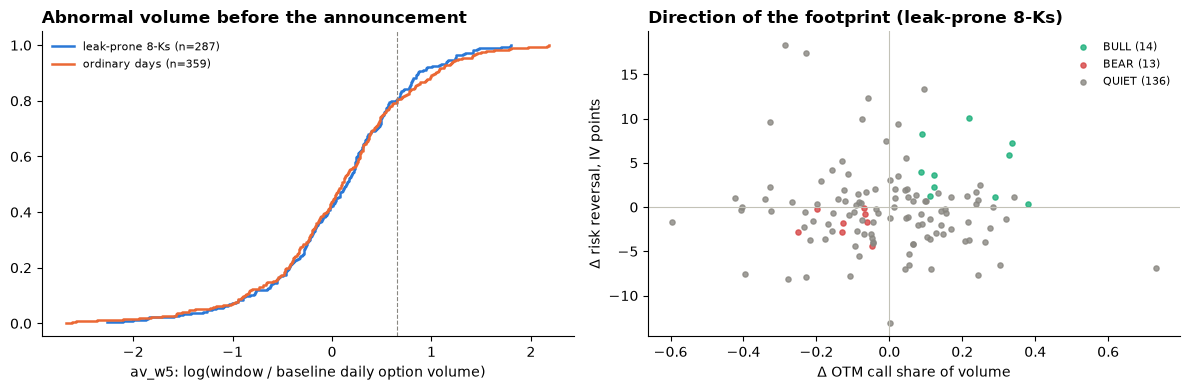

In [9]:
SERIES_COLORS = {"leak-prone 8-Ks": "#2a78d6", "ordinary days": "#eb6834", "earnings (control)": "#7a5bc7",
                 "other controls": "#1baf7a"}


def ecdf(ax, x, label):
    x = np.sort(np.asarray(x, dtype=float)[~np.isnan(np.asarray(x, dtype=float))])
    if len(x):
        ax.step(x, np.arange(1, len(x) + 1) / len(x), where="post", label=f"{label} (n={len(x)})",
                color=SERIES_COLORS.get(label), linewidth=1.8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ecdf(axes[0], ev_flow[f"av_w{TH['W']}"], "leak-prone 8-Ks")
ecdf(axes[0], pl_flow[f"av_w{TH['W']}"], "ordinary days")
axes[0].axvline(TH["av_hi"], color="#898781", linestyle="--", linewidth=0.8)
axes[0].set_title("Abnormal volume before the announcement", loc="left", fontweight="bold")
axes[0].set_xlabel(f"av_w{TH['W']}: log(window / baseline daily option volume)")
axes[0].legend(frameon=False, fontsize=8)
for cls, c in [("BULL", "#1baf7a"), ("BEAR", "#d64545"), ("QUIET", "#898781")]:
    s = ev_flow[ev_flow.flow_class == cls]
    axes[1].scatter(s[f"dcs_w{TH['W']}"], s[f"drr_w{TH['W']}"] * 100, s=14, color=c, label=f"{cls} ({len(s)})", alpha=0.8)
axes[1].axhline(0, color="#c3c2b7", linewidth=0.8)
axes[1].axvline(0, color="#c3c2b7", linewidth=0.8)
axes[1].set_title("Direction of the footprint (leak-prone 8-Ks)", loc="left", fontweight="bold")
axes[1].set_xlabel("Δ OTM call share of volume")
axes[1].set_ylabel("Δ risk reversal, IV points")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8 · The test: does the footprint predict, and only before a leak-prone 8-K?

Two readings, each with 95% bootstrap intervals (resampling within each cell):

1. **Signed drift (P1).** For BULL and BEAR events, the synthetic stock's return after entry, multiplied by
   the footprint's direction (+1 / −1). Positive means the stock went the way the flow pointed.
   Compared with the same footprint on ordinary days.
2. **The trade, as a 2 × 2.** For BULL: the long call's P&L in A (8-K + BULL), B (8-K + QUIET),
   C (ordinary + BULL), D (ordinary + QUIET), and the difference-in-differences (A − B) − (C − D).
   For BEAR: the same with the protective put.

`*` marks an interval that excludes zero. Read every horizon, not the best one (P2 predicts h ≤ 10).

P1 · Signed stock drift after a directional footprint (stock return × footprint direction). 3-6m synthetic, entry = post. * = 95% CI excludes zero.


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n (8-K / ordinary),23 / 31,24 / 31,22 / 31,23 / 29,22 / 30,22 / 29,20 / 29,20 / 28,21 / 27
after leak-prone 8-K,-0.03%,+0.18%,+1.09%*,-0.27%,+0.44%,+0.74%,-0.92%,+0.23%,-3.90%
after ordinary day,-0.18%,-0.23%,-0.58%,-1.03%,-1.04%,-0.26%,-1.25%,-5.99%,-4.48%
difference,+0.15%,+0.41%,+1.67%*,+0.76%,+1.48%,+1.00%,+0.34%,+6.22%,+0.58%
95% CI of difference,"[-0.82, +1.14]","[-0.79, +1.71]","[+0.19, +3.36]","[-2.20, +3.67]","[-2.28, +5.10]","[-3.49, +5.00]","[-6.01, +6.64]","[-2.74, +14.66]","[-11.04, +11.07]"



BULL footprint → 1 · Long call, 3-6m options, entry = post


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,12/119/9/150,12/119/9/150,12/120/9/149,12/119/8/148,11/117/9/149,12/120/9/150,11/116/9/146,11/112/9/148,11/114/9/149
A: 8-K + signal,-0.35%,-0.01%,+0.42%,-0.71%,-0.67%,-0.87%,-3.36%,+0.01%,-3.87%
B: 8-K + quiet,+0.10%,-0.01%,+0.24%,+0.34%,+0.57%,+1.27%,+1.96%,+2.41%,+3.14%
C: ordinary + signal,-0.11%,+0.00%,-0.31%,-0.51%,+0.40%,+2.07%,+5.21%,+6.04%,+6.79%
D: ordinary + quiet,+0.01%,+0.05%,-0.08%,-0.22%,-0.35%,+0.01%,-0.04%,+0.19%,+0.05%
event edge A − B,-0.46%,-0.00%,+0.18%,-1.05%,-1.23%,-2.14%,-5.31%*,-2.40%,-7.00%*
DiD (A − B) − (C − D),-0.33%,+0.05%,+0.41%,-0.76%,-1.98%,-4.20%,-10.57%*,-8.25%,-13.74%*
95% CI of DiD,"[-1.54, +0.63]","[-1.28, +1.30]","[-1.66, +2.52]","[-3.71, +2.11]","[-5.76, +1.75]","[-9.01, +0.41]","[-15.79, -5.50]","[-18.94, +2.05]","[-28.56, -1.97]"



BEAR footprint → 3 · Protective put (5% OTM), 3-6m options, entry = post


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,11/116/20/144,12/116/20/145,12/114/21/141,12/114/21/139,12/111/20/138,12/113/20/140,11/108/19/139,11/105/18/132,10/98/15/132
A: 8-K + signal,+0.07%,+0.03%,-0.45%,-0.06%,-1.43%,-1.13%,-1.06%,-0.20%,-0.75%
B: 8-K + quiet,+0.27%,+0.12%,+0.42%,+0.52%,+0.90%,+1.78%,+3.33%,+4.12%,+3.98%
C: ordinary + signal,+0.16%,+0.35%,+0.44%,+0.57%,+0.96%,+1.57%,+4.37%,+10.68%,+7.21%
D: ordinary + quiet,+0.04%,+0.18%,+0.06%,-0.15%,-0.32%,+0.17%,+0.88%,+0.61%,+0.43%
event edge A − B,-0.20%,-0.09%,-0.87%,-0.58%,-2.34%*,-2.91%*,-4.39%,-4.32%,-4.74%
DiD (A − B) − (C − D),-0.32%,-0.26%,-1.24%,-1.29%,-3.62%*,-4.31%*,-7.88%*,-14.39%*,-11.52%*
95% CI of DiD,"[-1.40, +0.80]","[-1.46, +1.06]","[-2.53, +0.07]","[-2.87, +0.36]","[-6.12, -1.13]","[-7.32, -1.24]","[-13.43, -1.70]","[-22.13, -6.98]","[-24.54, -0.03]"


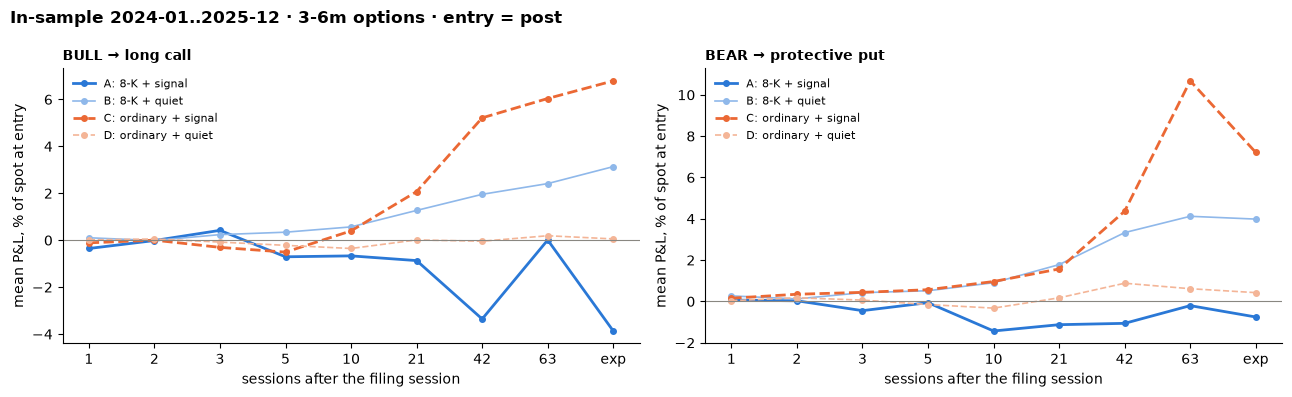

In [10]:
def boot_diff(groups: list[np.ndarray], signs: list[int], n_boot: int = 2000, seed: int = 0) -> tuple[float, float, float]:
    """Mean of sum(sign_i · mean(group_i)) with a percentile bootstrap CI, resampling each group independently."""
    if any(len(g) < 3 for g in groups):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    point = sum(s * g.mean() for g, s in zip(groups, signs))
    draws = sum(s * rng.choice(g, (n_boot, len(g))).mean(1) for g, s in zip(groups, signs))
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return point, lo, hi


def tag_results(res: pd.DataFrame, flow: pd.DataFrame, cls: pd.Series | None = None) -> pd.DataFrame:
    """Join each result row to its event's footprint class."""
    f = flow[["ticker", "event_date"]].assign(flow_class=cls if cls is not None else flow["flow_class"])
    return res.merge(f, on=["ticker", "event_date"], how="inner")


def horizons_in(*frames) -> list:
    have = set().union(*[set(f.horizon) for f in frames if len(f)])
    return [h for h in HORIZONS + ["exp"] if h in have]


def cut(r, bucket=None, entry=None, otm=None):
    return r[(r.bucket == (bucket or BASELINE_BUCKET)) & (r.entry == (entry or ENTRY)) & (r.otm == (otm or OTM_PCT))]


def signed_drift_table(ev_r: pd.DataFrame, pl_r: pd.DataFrame, **kw) -> pd.DataFrame:
    rows = []
    a, b = cut(ev_r, **kw), cut(pl_r, **kw)
    for h in horizons_in(a, b):
        def signed(r):
            r = r[(r.horizon == h) & r.flow_class.isin(["BULL", "BEAR"])]
            return (r["stock"] * np.where(r.flow_class == "BULL", 1, -1)).dropna().to_numpy()
        xa, xb = signed(a), signed(b)
        pa, la, ha = boot_diff([xa], [1])
        pb, lb, hb = boot_diff([xb], [1])
        pd_, ld, hd = boot_diff([xa, xb], [1, -1])
        rows.append({"horizon": h, "n_8k": len(xa), "8-K": pa, "8-K lo": la, "8-K hi": ha, "n_ord": len(xb),
                     "ordinary": pb, "ord lo": lb, "ord hi": hb, "difference": pd_, "diff lo": ld, "diff hi": hd})
    return pd.DataFrame(rows)


def did_table(ev_r: pd.DataFrame, pl_r: pd.DataFrame, signal: str, strategy: str, **kw) -> pd.DataFrame:
    a_all, c_all = cut(ev_r, **kw), cut(pl_r, **kw)
    rows = []
    for h in horizons_in(a_all, c_all):
        get = lambda r, c: r.loc[(r.horizon == h) & (r.flow_class == c), strategy].dropna().to_numpy()
        A, B, C, D = get(a_all, signal), get(a_all, "QUIET"), get(c_all, signal), get(c_all, "QUIET")
        did, lo, hi = boot_diff([A, B, C, D], [1, -1, -1, 1])
        ee, eel, eeh = boot_diff([A, B], [1, -1])
        rows.append({"horizon": h, "nA": len(A), "nB": len(B), "nC": len(C), "nD": len(D),
                     "A": A.mean() if len(A) else np.nan, "B": B.mean() if len(B) else np.nan,
                     "C": C.mean() if len(C) else np.nan, "D": D.mean() if len(D) else np.nan,
                     "event_edge": ee, "ee_lo": eel, "ee_hi": eeh, "did": did, "ci_lo": lo, "ci_hi": hi})
    return pd.DataFrame(rows)


def _p(v, lo=None, hi=None):
    if pd.isna(v):
        return ""
    star = "*" if lo is not None and pd.notna(lo) and (lo > 0 or hi < 0) else ""
    return f"{v * 100:+.2f}%{star}"


def fmt_drift(t: pd.DataFrame) -> pd.DataFrame:
    if t.empty:
        return t
    out = pd.DataFrame({
        "n (8-K / ordinary)": [f"{a} / {b}" for a, b in zip(t.n_8k, t.n_ord)],
        "after leak-prone 8-K": [_p(v, l, h) for v, l, h in zip(t["8-K"], t["8-K lo"], t["8-K hi"])],
        "after ordinary day": [_p(v, l, h) for v, l, h in zip(t.ordinary, t["ord lo"], t["ord hi"])],
        "difference": [_p(v, l, h) for v, l, h in zip(t.difference, t["diff lo"], t["diff hi"])],
        "95% CI of difference": [f"[{l * 100:+.2f}, {h * 100:+.2f}]" if pd.notna(l) else "" for l, h in zip(t["diff lo"], t["diff hi"])],
    }, index=[f"h={h}" if h != "exp" else "expiry" for h in t.horizon])
    return out.T


def fmt_did(t: pd.DataFrame) -> pd.DataFrame:
    if t.empty:
        return t
    out = pd.DataFrame({
        "n  A / B / C / D": [f"{a}/{b}/{c}/{d}" for a, b, c, d in zip(t.nA, t.nB, t.nC, t.nD)],
        "A: 8-K + signal": [_p(v) for v in t.A], "B: 8-K + quiet": [_p(v) for v in t.B],
        "C: ordinary + signal": [_p(v) for v in t.C], "D: ordinary + quiet": [_p(v) for v in t.D],
        "event edge A − B": [_p(v, l, h) for v, l, h in zip(t.event_edge, t.ee_lo, t.ee_hi)],
        "DiD (A − B) − (C − D)": [_p(v, l, h) for v, l, h in zip(t.did, t.ci_lo, t.ci_hi)],
        "95% CI of DiD": [f"[{l * 100:+.2f}, {h * 100:+.2f}]" if pd.notna(l) else "" for l, h in zip(t.ci_lo, t.ci_hi)],
    }, index=[f"h={h}" if h != "exp" else "expiry" for h in t.horizon])
    return out.T


def plot_did(tables: dict[str, pd.DataFrame], title: str):
    fig, axes = plt.subplots(1, len(tables), figsize=(6.5 * len(tables), 4), squeeze=False)
    colors = {"A": "#2a78d6", "B": "#8fb8ea", "C": "#eb6834", "D": "#f4b597"}
    names = {"A": "A: 8-K + signal", "B": "B: 8-K + quiet", "C": "C: ordinary + signal", "D": "D: ordinary + quiet"}
    for ax, (name, t) in zip(axes[0], tables.items()):
        if t.empty:
            continue
        x = np.arange(len(t))
        for k in "ABCD":
            ax.plot(x, t[k] * 100, color=colors[k], marker="o", markersize=4, linewidth=2 if k in "AC" else 1.2,
                    linestyle="-" if k in "AB" else "--", label=names[k])
        ax.axhline(0, color="#898781", linewidth=0.8)
        ax.set_xticks(x, [str(h) for h in t.horizon])
        ax.set_title(name, loc="left", fontweight="bold", fontsize=10)
        ax.set_xlabel("sessions after the filing session")
        ax.set_ylabel("mean P&L, % of spot at entry")
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle(title, x=0.01, ha="left", fontweight="bold")
    plt.tight_layout()
    plt.show()


ev_r, pl_r = tag_results(ev_res, ev_flow), tag_results(pl_res, pl_flow)
drift = signed_drift_table(ev_r, pl_r)
print(f"P1 · Signed stock drift after a directional footprint (stock return × footprint direction). "
      f"{BASELINE_BUCKET} synthetic, entry = {ENTRY}. * = 95% CI excludes zero.")
display(fmt_drift(drift))

did_bull = did_table(ev_r, pl_r, "BULL", "long_call")
did_bear = did_table(ev_r, pl_r, "BEAR", "protective_put")
print(f"\nBULL footprint → 1 · Long call, {BASELINE_BUCKET} options, entry = {ENTRY}")
display(fmt_did(did_bull))
print(f"\nBEAR footprint → 3 · Protective put ({OTM_PCT:.0%} OTM), {BASELINE_BUCKET} options, entry = {ENTRY}")
display(fmt_did(did_bear))
plot_did({"BULL → long call": did_bull, "BEAR → protective put": did_bear},
         f"In-sample {STUDY_START[:7]}..{STUDY_END[:7]} · {BASELINE_BUCKET} options · entry = {ENTRY}")

### Which events drove it

The largest contributors to the headline cell, with the filing text, so you can read what the footprint
was in front of. A result carried by two deals is not a result.

In [11]:
_top = cut(ev_r)
_top = _top[(_top.horizon == 10) & _top.flow_class.isin(["BULL", "BEAR"])].copy()
if len(_top):
    _top["trade"] = np.where(_top.flow_class == "BULL", _top.long_call, _top.protective_put)
    _top = _top.merge(ev_flow[["ticker", "event_date", "tag", "t_ann", "ann_lag_sessions", f"av_w{TH['W']}", "supporting_text"]],
                      on=["ticker", "event_date"])
    _top = _top.reindex(_top.trade.abs().sort_values(ascending=False).index).head(10)
    with pd.option_context("display.max_colwidth", 90):
        display(_top[["ticker", "tag", "event_date", "t_ann", "flow_class", f"av_w{TH['W']}", "realized", "trade", "supporting_text"]]
                .assign(realized=lambda d: d.realized.map("{:+.1%}".format), trade=lambda d: d.trade.map("{:+.1%}".format))
                .reset_index(drop=True))
else:
    print("No directional events priced at h=10.")

,ticker,tag,event_date,t_ann,flow_class,av_w5,realized,trade,supporting_text
0,LMT,guidance_issuance_or_update,2024-07-19,2024-07-19,BULL,1.241900,+15.0%,+11.7%,Our expectation remains that we will continue with a production rate of 156 aircraft p...
1,CHTR,material_litigation,2025-07-21,2025-07-10,BULL,0.948993,+nan%,-10.0%,Following the announcement of the Transaction Agreement and as of the date of this Cur...
2,MSFT,executive_officer_departure,2025-01-22,2025-01-22,BEAR,0.947010,-7.6%,-6.1%,"On January 22, 2025, Christopher D. Young informed Microsoft Corporation (the ""Company..."
3,NOW,share_repurchase_program,2025-01-29,2025-01-29,BULL,1.334976,-13.4%,-6.0%,"On January 29, 2025, ServiceNow announced that its Board of Directors authorized an ad..."
4,UNH,executive_officer_departure,2025-04-29,2025-04-29,BULL,0.843827,-24.1%,-5.7%,"Heather Cianfrocco, currently Chief Executive Officer of Optum, has been appointed to ..."
5,BA,public_offering,2024-10-31,2024-10-31,BEAR,1.700443,-6.4%,-4.0%,"The Company agreed to issue and sell 100,000,000 depositary shares (the ""Depositary Sh..."
6,MET,executive_officer_departure,2025-01-10,2025-01-07,BULL,1.419817,+7.3%,+3.7%,"On January 7, 2025, Tamara L. Schock, Executive Vice President and Chief Accounting Of..."
7,PYPL,executive_officer_departure,2024-01-08,2024-01-08,BULL,1.071094,+5.0%,+3.2%,"On January 8, 2024, PayPal, Inc. and Peggy Alford, the Company's Executive Vice Presid..."
8,BMY,executive_officer_departure,2025-07-25,2025-07-25,BULL,1.472957,-5.8%,-3.0%,"On July 25, 2025, Bristol-Myers Squibb Company (the ""Company"") announced that Dr. Sami..."
9,DUK,executive_officer_departure,2025-05-05,2025-04-29,BEAR,0.695405,-3.3%,-3.0%,"On April 29, 2025, Ms. Julia S. Janson, currently serving as Duke Energy Corporation's..."


## 9 · Negative controls (P3)

The same footprint, the same frozen thresholds, the same trade, on 8-K categories where there is nothing
to leak (director appointments, equity grants, charter amendments) and on scheduled earnings, where volume
before the date is anticipation that everyone shares. The BULL-minus-QUIET edge here should be near zero;
if it is as large as for leak-prone events, the footprint is a generic momentum signal and the 8-K
category adds nothing.

  control footprints: 50/284 (6s)


  control footprints: 100/284 (12s)


  control footprints: 150/284 (18s)


  control footprints: 200/284 (25s)


  control footprints: 250/284 (31s)


...

  pricing controls: 150/284 (28s)


  pricing controls: 200/284 (38s)


  pricing controls: 250/284 (48s)


  pricing controls: 284 done in 54s, 0 failed


flow_class,BULL,BEAR,MIXED,NORMAL,QUIET,NA
tag,,,,,,
charter_amendment,0,2,5,11,16,2
director_appointment,4,7,9,24,47,6
equity_compensation_grant,1,1,0,5,12,1
quarterly_earnings,3,7,18,40,54,9


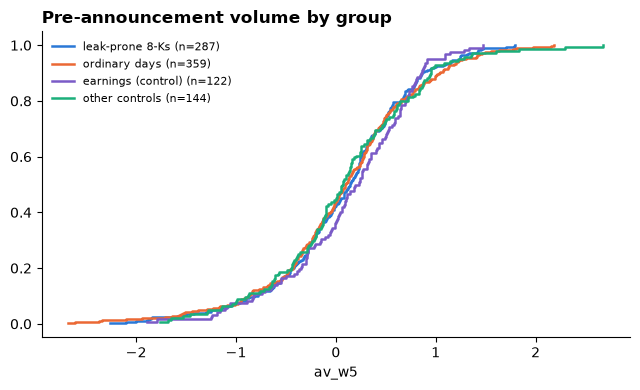

Long-call event edge A − B (BULL minus QUIET), 3-6m, entry = post. Controls should be ≈ 0.


horizon,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
group,,,,,,,,,
earnings (control),+1.18%* (n 3/49),+1.20%* (n 3/49),+0.90% (n 3/49),-0.59% (n 3/49),-1.13% (n 3/46),-0.98% (n 3/46),-0.28% (n 3/44),-0.30% (n 3/45),-4.63%* (n 3/48)
leak-prone 8-Ks,-0.46% (n 12/119),-0.00% (n 12/119),+0.18% (n 12/120),-1.05% (n 12/119),-1.23% (n 11/117),-2.14% (n 12/120),-5.31%* (n 11/116),-2.40% (n 11/112),-7.00%* (n 11/114)
other controls,-0.42% (n 5/66),-0.54% (n 5/67),-1.00% (n 5/66),-0.58% (n 5/64),-1.18% (n 5/64),-4.52%* (n 5/59),-5.38% (n 5/64),-6.07% (n 5/61),-2.93% (n 5/58)


In [12]:
if RUN_NEGATIVE_CONTROLS:
    ctrl = limit_events(control_events, MAX_EVENTS)
    ctrl_flow = add_flow(ctrl, "t_ann", "control footprints")
    ctrl_flow["flow_class"] = classify(ctrl_flow, TH)
    ctrl_priced, _ = price_events(ctrl, label="pricing controls")
    ctrl_r = tag_results(evaluate(ctrl_priced), ctrl_flow)
    display(ctrl_flow.groupby("tag").flow_class.value_counts().unstack().reindex(columns=CLASSES).fillna(0).astype(int))

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ecdf(ax, ev_flow[f"av_w{TH['W']}"], "leak-prone 8-Ks")
    ecdf(ax, pl_flow[f"av_w{TH['W']}"], "ordinary days")
    ecdf(ax, ctrl_flow.loc[ctrl_flow.tag == "quarterly_earnings", f"av_w{TH['W']}"], "earnings (control)")
    ecdf(ax, ctrl_flow.loc[ctrl_flow.tag != "quarterly_earnings", f"av_w{TH['W']}"], "other controls")
    ax.set_title("Pre-announcement volume by group", loc="left", fontweight="bold")
    ax.set_xlabel(f"av_w{TH['W']}")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    ctrl_r = ctrl_r.merge(ctrl_flow[["ticker", "event_date", "tag"]], on=["ticker", "event_date"], how="left")
    rows = []
    for name, r in [("leak-prone 8-Ks", ev_r), ("earnings (control)", ctrl_r[ctrl_r.tag == "quarterly_earnings"]),
                    ("other controls", ctrl_r[ctrl_r.tag != "quarterly_earnings"])]:
        t = did_table(r, pl_r, "BULL", "long_call")
        for _, x in t.iterrows():
            rows.append({"group": name, "horizon": f"h={x.horizon}" if x.horizon != "exp" else "expiry",
                         "cell": f"{_p(x.event_edge, x.ee_lo, x.ee_hi)} (n {x.nA}/{x.nB})"})
    print(f"Long-call event edge A − B (BULL minus QUIET), {BASELINE_BUCKET}, entry = {ENTRY}. Controls should be ≈ 0.")
    if rows:
        display(pd.DataFrame(rows).pivot(index="group", columns="horizon", values="cell")
                  .reindex(columns=[c for c in [f"h={h}" for h in HORIZONS] + ["expiry"] if c in {r['horizon'] for r in rows}]))
else:
    print("Skipped (RUN_NEGATIVE_CONTROLS = False).")

## 10 · Parameter sensitivity

One knob at a time around the baseline, everything else held. Each row re-derives the thresholds from
ordinary days where the knob changes them. Cells are the DiD at three horizons, `*` where the 95%
interval excludes zero. A finding has to keep its sign along a row's neighbours.

In [13]:
SENS_HORIZONS = [5, 10, 21]
if any(ev_flow.ann_lag_sessions > 0):
    ev_flow_filing = add_flow(events, "t_0", "filing-aligned footprints")   # window ends before the filing, not the announcement
else:
    ev_flow_filing = ev_flow


def variant(name, *, W=None, hi_q=None, rule=None, bucket=None, entry=None, otm=None, align="ann", tags=None):
    th = learn_thresholds(pl_flow, W=W, hi_q=hi_q) if (W or hi_q) and FROZEN_THRESHOLDS is None else TH
    ef = ev_flow_filing if align == "filing" else ev_flow
    er = tag_results(ev_res, ef, classify(ef, th, rule))
    if tags is not None:
        er = er.merge(ef[["ticker", "event_date", "tag"]], on=["ticker", "event_date"])
        er = er[er.tag.isin(tags)]
    pr = tag_results(pl_res, pl_flow, classify(pl_flow, th, rule))
    out = {"variant": name}
    for signal, strat in [("BULL", "long_call"), ("BEAR", "protective_put")]:
        t = did_table(er, pr, signal, strat, bucket=bucket, entry=entry, otm=otm).set_index("horizon")
        for h in SENS_HORIZONS:
            if h in t.index:
                x = t.loc[h]
                out[(f"{signal} → {STRATEGY_LABEL[strat]}", f"h={h}")] = f"{_p(x.did, x.ci_lo, x.ci_hi)} ({int(x.nA)})"
    return out


rows = [variant("baseline")]
rows += [variant(f"window {w} sessions", W=w) for w in FLOW_WINDOW_GRID if w != FLOW_WINDOW]
rows += [variant(f"abnormal = top {1 - q:.0%} of ordinary days", hi_q=q) for q in AV_HI_Q_GRID if q != AV_HI_Q]
rows += [variant(f"direction from {r}", rule=r) for r in ("both", "cs", "rr") if r != DIRECTION_RULE]
rows += [variant(f"bucket {b}", bucket=b) for b in EXPIRY_BUCKETS if b != BASELINE_BUCKET]
rows += [variant("entry pre (pricing test, not tradeable)" if ENTRY == "post" else "entry post", entry="pre" if ENTRY == "post" else "post")]
rows += [variant(f"put {o:.0%} OTM", otm=o) for o in OTM_GRID if o != OTM_PCT]
rows += [variant("window aligned to filing date, not announcement", align="filing")]
rows += [variant("without executive_officer_departure", tags=[t for t in LEAK_TAGS if t != "executive_officer_departure"])]
rows += [variant("M&A + guidance + restructuring + exits only",
                 tags=["acquisition_agreement", "guidance_issuance_or_update", "restructuring_plan", "business_line_exit"])]
sens = pd.DataFrame(rows).set_index("variant")
sens.columns = pd.MultiIndex.from_tuples(sens.columns)
print("DiD (A − B) − (C − D), % of spot; (n) = events in cell A. * = 95% CI excludes zero.")
display(sens.fillna(""))

  filing-aligned footprints: 50/318 (2s)


  filing-aligned footprints: 100/318 (3s)


  filing-aligned footprints: 150/318 (5s)


  filing-aligned footprints: 200/318 (9s)


  filing-aligned footprints: 250/318 (10s)


  filing-aligned footprints: 300/318 (12s)


  filing-aligned footprints: 318 done in 13s, 0 failed


DiD (A − B) − (C − D), % of spot; (n) = events in cell A. * = 95% CI excludes zero.


BULL → 1 · Long call  \
                                                                 h=5   
variant                                                                
baseline                                                 -0.76% (12)   
window 3 sessions                                        -1.76% (18)   
window 10 sessions                                      -2.51%* (11)   
abnormal = top 30% of ordinary days                      -0.90% (19)   
abnormal = top 10% of ordinary days                       -1.67% (7)   
direction from cs                                        -0.45% (27)   
direction from rr                                       -2.00%* (22)   
bucket 1m                                                -1.29% (10)   
bucket 2m                                                -1.09% (11)   
entry pre (pricing test, not tradeable)                  -1.84% (12)   
put 3% OTM                                               -0.76% (12)   
put 10% OTM                                              -0.76% (12)   
window aligned to filing date, not announcement          -1.67% (10)   
without executive_officer_departure                       -1.05% (4)   
M&A + guidance + restructuring + exits only                      (1)   

                                                                             \
                                                         h=10          h=21   
variant                                                                       
baseline                                          -1.98% (11)   -4.20% (12)   
window 3 sessions                                 -2.96% (17)  -5.45%* (18)   
window 10 sessions                                -2.78% (11)   -4.10% (11)   
abnormal = top 30% of ordinary days               -2.05% (18)  -4.24%* (19)   
abnormal = top 10% of ordinary days                -0.27% (7)    -1.93% (7)   
direction from cs                                 -1.28% (26)   -2.60% (27)   
direction from rr                                -3.07%* (21)  -3.07%* (22)   
bucket 1m                                          -0.79% (9)           (2)   
bucket 2m                                         -2.04% (11)   -3.26% (10)   
entry pre (pricing test, not tradeable)           -3.11% (11)  -5.21%* (12)   
put 3% OTM                                        -1.98% (11)   -4.20% (12)   
put 10% OTM                                       -1.98% (11)   -4.20% (12)   
window aligned to filing date, not announcement   -2.60% (10)   -4.33% (10)   
without executive_officer_departure                -2.89% (3)    -3.74% (4)   
M&A + guidance + restructuring + exits only               (1)           (1)   

                                                BEAR → 3 · Protective put  \
                                                                      h=5   
variant                                                                     
baseline                                                      -1.29% (12)   
window 3 sessions                                             -1.06% (13)   
window 10 sessions                                             -0.49% (8)   
abnormal = top 30% of ordinary days                           -1.25% (17)   
abnormal = top 10% of ordinary days                           -2.64%* (3)   
direction from cs                                            -2.36%* (26)   
direction from rr                                             -1.14% (22)   
bucket 1m                                                      -0.92% (7)   
bucket 2m                                                     -0.86% (10)   
entry pre (pricing test, not tradeable)                       -0.36% (12)   
put 3% OTM                                                    -1.60% (11)   
put 10% OTM                                                   -1.73% (10)   
window aligned to filing date, not announcement               -1.10% (12)   
without executive_officer_departure                            -1.10% (7)   
M&A + guidance + re

## 11 · Out-of-sample, and the function judges call

`run_study(start, end)` is the whole pipeline on a fresh window with the **frozen** in-sample thresholds:
events, ordinary days, footprints, classification, pricing and the 2 × 2. Out-of-sample runs it on
`OOS_START..OOS_END`; the sealed window runs it on the judges' dates. Horizons that have not resolved are
absent, not zero.

  2026-01-01..2026-08-31 footprints: 50/120 (6s)


  2026-01-01..2026-08-31 footprints: 100/120 (12s)


  2026-01-01..2026-08-31 footprints: 120 done in 16s, 0 failed


  2026-01-01..2026-08-31 placebo footprints: 50/184 (7s)


  2026-01-01..2026-08-31 placebo footprints: 100/184 (15s)


...

,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,8/43/7/80,8/43/7/77,8/42/6/79,8/43/7/79,8/40/7/80,8/41/5/80,8/38/7/68,7/35/6/51,6/30/6/50
A: 8-K + signal,-1.62%,-1.84%,-1.13%,-1.73%,-1.03%,-2.27%,-0.94%,+4.09%,+2.71%
B: 8-K + quiet,+0.33%,+0.26%,+0.42%,+0.62%,+1.40%,+4.78%,+4.24%,+3.26%,+5.35%
C: ordinary + signal,+0.50%,+1.14%,+1.06%,-0.19%,-1.50%,+1.24%,+2.23%,-2.66%,-6.78%
D: ordinary + quiet,-0.37%,-0.04%,+0.08%,+0.02%,+0.49%,+0.41%,+1.77%,+2.34%,+3.75%
event edge A − B,-1.94%*,-2.10%*,-1.55%,-2.34%*,-2.43%,-7.06%*,-5.18%,+0.83%,-2.64%
DiD (A − B) − (C − D),-2.82%*,-3.29%*,-2.53%,-2.14%,-0.44%,-7.89%,-5.64%,+5.83%,+7.90%
95% CI of DiD,"[-4.63, -1.09]","[-5.43, -1.43]","[-5.63, +0.41]","[-4.80, +0.47]","[-4.60, +3.37]","[-17.36, +0.45]","[-21.14, +6.45]","[-7.31, +19.41]","[-5.48, +21.79]"



BEAR → 3 · Protective put, out-of-sample


,h=1,h=2,h=3,h=5,h=10,h=21,h=42,h=63,expiry
n A / B / C / D,3/39/6/78,3/39/6/74,3/40/6/76,3/39/5/76,3/39/6/77,3/39/6/74,3/34/5/61,2/33/6/41,2/23/4/42
A: 8-K + signal,-5.09%,-5.89%,-4.69%,-5.12%,-6.03%,-6.12%,-7.94%,-10.46%,-8.94%
B: 8-K + quiet,+0.49%,+0.31%,+0.34%,+0.99%,+1.54%,+5.57%,+5.27%,+3.16%,+2.09%
C: ordinary + signal,-0.24%,-0.10%,-0.29%,+0.09%,+1.51%,+4.79%,-3.68%,-3.03%,-5.90%
D: ordinary + quiet,-0.31%,+0.06%,+0.20%,+0.26%,+0.81%,+1.20%,+2.82%,+4.45%,+6.39%
event edge A − B,-5.58%*,-6.20%*,-5.03%,-6.12%,-7.57%*,-11.69%*,-13.21%*,,
DiD (A − B) − (C − D),-5.64%*,-6.03%*,-4.54%,-5.95%,-8.27%*,-15.28%*,-6.72%,,
95% CI of DiD,"[-9.70, -1.30]","[-11.28, -1.06]","[-10.67, +2.09]","[-12.99, +1.21]","[-14.39, -1.86]","[-27.37, -4.07]","[-18.59, +3.70]",,



In-sample → out-of-sample


h=1     h=2     h=3     h=5    h=10  \
signed drift difference in-sample      +0.15%  +0.41%  +1.67%  +0.76%  +1.48%   
                        out-of-sample  -0.57%  -1.17%  -0.82%  +0.08%  +1.00%   
                        same sign           ✗       ✗       ✗       ✓       ✓   
BULL long-call DiD      in-sample      -0.33%  +0.05%  +0.41%  -0.76%  -1.98%   
                        out-of-sample  -2.82%  -3.29%  -2.53%  -2.14%  -0.44%   
                        same sign           ✓       ✗       ✗       ✓       ✓   
BEAR protective-put DiD in-sample      -0.32%  -0.26%  -1.24%  -1.29%  -3.62%   
                        out-of-sample  -5.64%  -6.03%  -4.54%  -5.95%  -8.27%   
                        same sign           ✓       ✓       ✓       ✓       ✓   

                                          h=21     h=42     h=63   expiry  
signed drift difference in-sample       +1.00%   +0.34%   +6.22%   +0.58%  
                        out-of-sample   +5.75%   +4.30%   +9.78%   +2.90%  
                        same sign            ✓        ✓        ✓        ✓  
BULL long-call DiD      in-sample       -4.20%  -10.57%   -8.25%  -13.74%  
                        out-of-sample   -7.89%   -5.64%   +5.83%   +7.90%  
                        same sign            ✓        ✓        ✗        ✗  
BEAR protective-put DiD in-sample       -4.31%   -7.88%  -14.39%  -11.52%  
                        out-of-sample  -15.28%   -6.72%                    
                        same sign            ✓        ✓

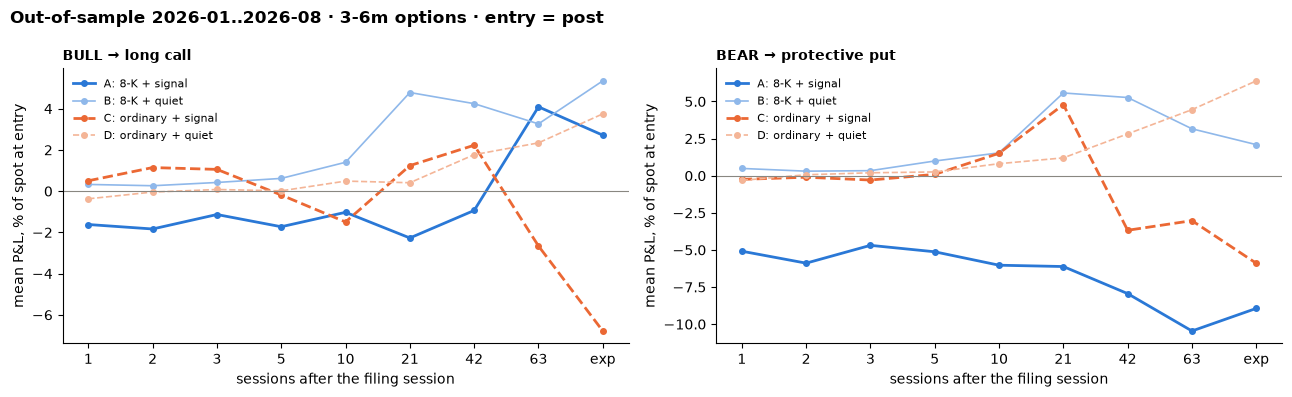

In [14]:
def run_study(start: str, end: str, thresholds: dict = None, n_placebo: int = None, max_events: int | None = None,
              label: str = None) -> dict:
    """Events, ordinary days, footprints, frozen classification, pricing and the 2 × 2 for one window."""
    label = label or f"{start}..{end}"
    th = thresholds or TH
    ev = limit_events(build_events(LEAK_TAGS, start, end), max_events if max_events is not None else MAX_EVENTS)
    ctl = build_events(CONTROL_TAGS, start, end)
    pl = sample_placebo(ev, n_placebo or N_PLACEBO_OOS, start, end, known_8k_dates(ev, ctl), seed=11)
    ef, pf = add_flow(ev, "t_ann", f"{label} footprints"), add_flow(pl, "t_ann", f"{label} placebo footprints")
    ef["flow_class"], pf["flow_class"] = classify(ef, th), classify(pf, th)
    ep, _ = price_events(ev, label=f"{label} pricing")
    pp, _ = price_events(pl, label=f"{label} placebo pricing")
    er, pr = tag_results(evaluate(ep), ef), tag_results(evaluate(pp), pf)
    return {"events": ev, "placebo": pl, "ev_flow": ef, "pl_flow": pf, "ev_r": er, "pl_r": pr,
            "drift": signed_drift_table(er, pr),
            "did_bull": did_table(er, pr, "BULL", "long_call"), "did_bear": did_table(er, pr, "BEAR", "protective_put")}


oos = run_study(OOS_START, OOS_END, TH, N_PLACEBO_OOS)
print(f"Out-of-sample {OOS_START}..{OOS_END}: {len(oos['events'])} events; classes "
      f"{oos['ev_flow'].flow_class.value_counts().reindex(CLASSES).fillna(0).astype(int).to_dict()}")
print("\nP1 · Signed drift, out-of-sample")
display(fmt_drift(oos["drift"]))
print("\nBULL → 1 · Long call, out-of-sample")
display(fmt_did(oos["did_bull"]))
print("\nBEAR → 3 · Protective put, out-of-sample")
display(fmt_did(oos["did_bear"]))


def in_vs_out(a: pd.DataFrame, b: pd.DataFrame, col: str) -> pd.DataFrame:
    m = a[["horizon", col]].merge(b[["horizon", col]], on="horizon", suffixes=("_in", "_oos"))
    a_, b_ = m[f"{col}_in"].to_numpy(float), m[f"{col}_oos"].to_numpy(float)
    same = np.where(np.isnan(a_) | np.isnan(b_), "", np.where(np.sign(a_) == np.sign(b_), "✓", "✗"))
    return pd.DataFrame({"in-sample": [_p(v) for v in a_], "out-of-sample": [_p(v) for v in b_], "same sign": same},
                        index=[f"h={h}" if h != "exp" else "expiry" for h in m.horizon]).T


print("\nIn-sample → out-of-sample")
display(pd.concat({"signed drift difference": in_vs_out(drift, oos["drift"], "difference"),
                   "BULL long-call DiD": in_vs_out(did_bull, oos["did_bull"], "did"),
                   "BEAR protective-put DiD": in_vs_out(did_bear, oos["did_bear"], "did")}))
plot_did({"BULL → long call": oos["did_bull"], "BEAR → protective put": oos["did_bear"]},
         f"Out-of-sample {OOS_START[:7]}..{OOS_END[:7]} · {BASELINE_BUCKET} options · entry = {ENTRY}")

## 12 · Trade realism: real spreads and capacity

This key includes options quotes, so the cost is the **actual closing bid-ask** rather than a haircut:
half the spread to get in at `t_0` and half to get out at h = 10, for every BULL long call in the headline
bucket. Capacity: the ATM call's volume on the entry session, and the notional you could trade at 10% of it.

In [15]:
def closing_quote(opt_ticker: str, day) -> tuple[float, float]:
    """Last NBBO at or before 16:00 ET on `day`; NaNs if none that day."""
    day = pd.Timestamp(day)
    close_ns = (day.tz_localize("America/New_York") + pd.Timedelta(hours=16)).value
    p = api_get(f"/v3/quotes/{opt_ticker}", {"timestamp.lte": close_ns, "order": "desc", "sort": "timestamp", "limit": 1})
    r = (p.get("results") or [None])[0]
    if not r or r.get("sip_timestamp", 0) < day.tz_localize("America/New_York").value:
        return np.nan, np.nan
    return float(r.get("bid_price") or np.nan), float(r.get("ask_price") or np.nan)


EXIT_H = 10
bull = cut(ev_r)
bull = bull[(bull.flow_class == "BULL") & (bull.horizon == EXIT_H)]
pe_by_key = {(p.ticker, p.event_date): p for p in ev_priced if p.bucket == BASELINE_BUCKET}


def cost_row(r):
    pe = pe_by_key[(r["ticker"], r["event_date"])]
    leg = pe.legs["C_K"]
    b0, a0 = closing_quote(leg.ticker, r["entry_date"])
    b1, a1 = closing_quote(leg.ticker, r["exit_date"])
    half = ((a0 - b0) + (a1 - b1)) / 2
    vol0 = leg.volume_on(r["entry_date"])
    return {"ticker": r["ticker"], "event_date": r["event_date"], "contract": leg.ticker,
            "spread_entry_pct_premium": (a0 - b0) / ((a0 + b0) / 2) if a0 + b0 > 0 else np.nan,
            "cost": half / r["S_entry"], "gross": r["long_call"], "net": r["long_call"] - half / r["S_entry"],
            "entry_volume": vol0, "premium": (a0 + b0) / 2,
            "notional_at_10pct_of_volume": 0.10 * vol0 * 100 * (a0 + b0) / 2}


if len(bull):
    costs = pd.DataFrame([c for c in pmap(cost_row, bull.to_dict("records"), "quotes") if c is not None])
    summary = pd.Series({
        "events (BULL, priced at h=10)": f"{len(costs)}",
        "gross mean long-call P&L, % of spot": f"{costs.gross.mean() * 100:+.2f}%",
        "mean round-trip cost from real spreads, % of spot": f"{costs.cost.mean() * 100:.2f}%",
        "net mean P&L, % of spot": f"{costs.net.mean() * 100:+.2f}%",
        "share of gross edge eaten by spreads": f"{costs.cost.mean() / costs.gross.mean():.0%}" if costs.gross.mean() > 0 else "n/a (no gross edge)",
        "median entry spread, % of premium": f"{costs.spread_entry_pct_premium.median():.1%}",
        "median ATM call volume on entry session": f"{costs.entry_volume.median():,.0f} contracts",
        "median notional at 10% of that volume": f"${costs.notional_at_10pct_of_volume.median():,.0f} premium",
        "events per year": f"{len(costs) / max((pd.Timestamp(STUDY_END) - pd.Timestamp(STUDY_START)).days / 365, 1e-9):.1f}",
    })
    display(summary.to_frame("value"))
else:
    print("No BULL events priced at the exit horizon.")

  quotes: 12 done in 1s, 0 failed


,value
"events (BULL, priced at h=10)",12
"gross mean long-call P&L, % of spot",-0.67%
"mean round-trip cost from real spreads, % of spot",0.26%
"net mean P&L, % of spot",-0.93%
share of gross edge eaten by spreads,n/a (no gross edge)
"median entry spread, % of premium",3.3%
median ATM call volume on entry session,18 contracts
median notional at 10% of that volume,"$2,048 premium"
events per year,6.0


## Sealed window · judges only

Set `HOLDOUT_START`, `HOLDOUT_END` and `RUN_HOLDOUT = True` in section 2 and run all. The thresholds are
the ones learned in-sample above; nothing is re-fit on your window.

In [16]:
if RUN_HOLDOUT:
    holdout = run_study(HOLDOUT_START, HOLDOUT_END, TH, N_PLACEBO_OOS, label="sealed")
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END}: {len(holdout['events'])} events")
    display(fmt_drift(holdout["drift"]))
    display(fmt_did(holdout["did_bull"]))
    display(fmt_did(holdout["did_bear"]))
    plot_did({"BULL → long call": holdout["did_bull"], "BEAR → protective put": holdout["did_bear"]},
             f"Sealed window {HOLDOUT_START}..{HOLDOUT_END}")
else:
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END} not run. Judges: set RUN_HOLDOUT = True.")

Sealed window 2023-06-01..2023-08-31 not run. Judges: set RUN_HOLDOUT = True.


## Limitations to state in the write-up

- **Unsigned volume.** Daily bars do not say who initiated a trade. The risk-reversal change is the
  signing proxy; a stretch is Lee-Ready signing from `/v3/trades` against `/v3/quotes`, which this key can
  reach but which costs one request per trade.
- **Sampled chain.** The footprint reads 16 contracts per event (2 expiries × ATM, 3%, 6%, 10% each
  side), not the whole chain, to keep the request count sane. Massive Flat Files (one file per day with
  every contract) would give the full chain at lower cost.
- **Announcement date from text.** The regex can pick up a date that is not the announcement (an
  agreement dated before it was public). The sensitivity row "aligned to filing date" bounds the effect.
- **Acquirers, not targets.** The universe is the 100 largest companies; most M&A here is on the
  acquiring side, where leakage is weaker (P4).
- **Static universe, parity spot, synthetic stock, last-trade marks, no earnings calendar**: as in the
  starter's appendix. Ordinary days are kept clear of every known 8-K, including earnings, which handles
  the biggest of these.